In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("reels_attention_span_dataset_12000.csv")

In [3]:
df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   reels_watch_time_hours   12000 non-null  float64
 3   daily_screen_time_hours  12000 non-null  float64
 4   sleep_hours              12000 non-null  float64
 5   attention_span_score     12000 non-null  float64
 6   focus_level              12000 non-null  float64
 7   task_completion_rate     12000 non-null  float64
 8   stress_level             12000 non-null  object 
 9   platform                 12000 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 937.6+ KB


In [5]:
df["stress_level"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [6]:
df["stress_level_num"]=df["stress_level"].map({
    "Low":1,
    "Medium":2,
    "High":3
})
df.head(1)

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,stress_level_num
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,2


In [7]:
df["platform"].unique()

array(['TikTok', 'Instagram Reels', 'YouTube Shorts'], dtype=object)

<Axes: >

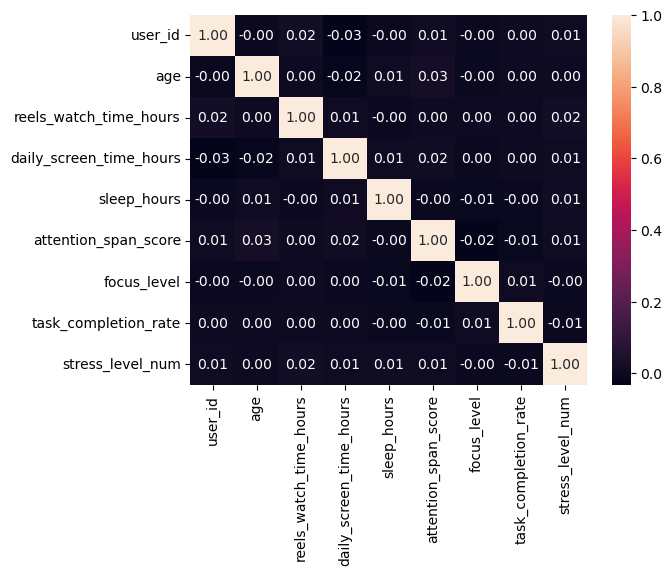

In [8]:
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(),annot=True,fmt=".2f")

Kullanıcıların stres seviyeleri veya odaklanma düzeyleri ile reels izleme süreleri, günlük ekran süreleri veya uyku saatleri arasında istatistiksel olarak anlamlı bir korelasyon bulunamamıştır.

In [18]:
df["age_group"]=pd.cut(df["age"],bins=[15,25,35,45,55,65,75])
df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,stress_level_num,age_group
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,2,"(15, 25]"
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok,3,"(25, 35]"
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok,1,"(35, 45]"
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels,1,"(25, 35]"
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels,1,"(15, 25]"


In [19]:
df.groupby("platform")["reels_watch_time_hours"].mean()

platform
Instagram Reels    3.233761
TikTok             3.257937
YouTube Shorts     3.240670
Name: reels_watch_time_hours, dtype: float64

In [20]:
df.groupby("platform")["stress_level_num"].mean()

platform
Instagram Reels    2.007191
TikTok             2.017026
YouTube Shorts     1.990939
Name: stress_level_num, dtype: float64

In [21]:
df.groupby("platform")["focus_level"].mean()

platform
Instagram Reels    5.486296
TikTok             5.512128
YouTube Shorts     5.540345
Name: focus_level, dtype: float64

In [23]:
df["age_group"].unique()

[(15.0, 25.0], (25.0, 35.0], (35.0, 45.0], NaN]
Categories (6, interval[int64, right]): [(15, 25] < (25, 35] < (35, 45] < (45, 55] < (55, 65] < (65, 75]]

In [24]:
df["age_group"].astype(str)

0        (15, 25]
1        (25, 35]
2        (35, 45]
3        (25, 35]
4        (15, 25]
           ...   
11995    (25, 35]
11996    (35, 45]
11997    (15, 25]
11998    (35, 45]
11999    (25, 35]
Name: age_group, Length: 12000, dtype: object

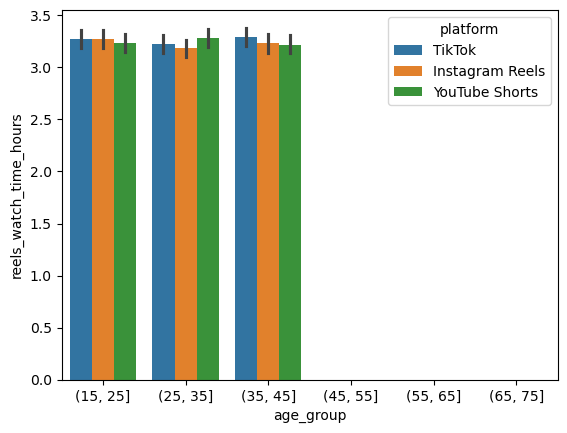

In [25]:
sns.barplot(y="reels_watch_time_hours",x="age_group",data=df,hue="platform")
plt.show()

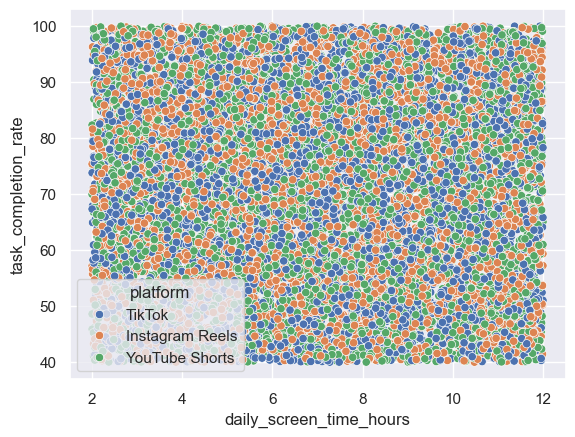

In [31]:
sns.set_theme(style="darkgrid",palette="deep")
sns.scatterplot(data=df, x="daily_screen_time_hours",y="task_completion_rate",hue="platform")
plt.show()

Görev tamamlama oranı ile günlük ekran süresi arasında anlamlı bir ilişki yoktur

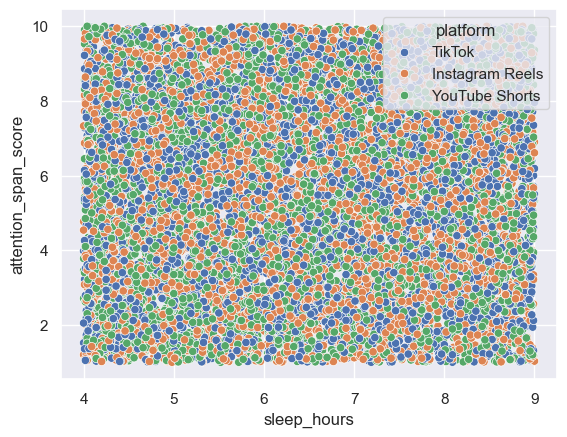

In [33]:
sns.scatterplot(data=df,y="attention_span_score",x="sleep_hours",hue="platform")
plt.show()

uyku süresi ile görev tamamlama arasında anlamlı bir ilişki yoktur